# CONTIGO: Energy Dissipation Rate and Effective Density

### Running In Google Colab

Click the badge below run and run the Colab cell to get setup 

<a href="https://colab.research.google.com/github/kylermurphy/contigo_edr/blob/main/notebooks/Tutorial_Overview.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
## Colab Setup
import sys
import os

IN_COLAB = 'google.colab' in sys.modules

print(f"Running in Colab: {IN_COLAB}")

if IN_COLAB:
  try:
    import contigo
    print("Library already loaded!")
  except ImportError:
    print("Istalling contigo and Restarting kernel...")
    !git clone https://github.com/kylermurphy/contigo_edr
    !cd contigo_edr ; pip install -e . -q
    os.kill(os.getpid(), 9)

Running in Colab: False


## CONTIGO Tutorial

The ```contigo``` module derives the energy dissapation rate (EDR) and effectived density
(EFD) for Earth-orbiting spacecraft. It implements the EDR and EFD calculation in Earth
Centered Earth Fixed (ECEF) coordinates following the implementation from [Fitzpatrick et
al. (2025)](https://doi.org/10.1029/2024EA003898Digital).


### Energy Dissipation Rate (EDR)

The EDR is derived from a spacecrafts state vector, the earth potential at the location
of the spacecraft, and the non-coservative forces acting on the spacecraft. In ECEF
coordinates the EDR (${\Delta }\xi$) between times ${t}_{1}$ and ${t}_{0}$ can be calculated by:

$$
{}^{\mathcal{B}}{\Delta }\xi ={\left.\left(\frac{{}^{\mathcal{B}}\dot{r}^{2}}{2}-{W}_{\mathrm{g}}\right)\right\vert}_{{t}_{0}}^{{t}_{1}}-\underset{{t}_{0}{}}{\overset{{t}_{1}}{\int }}{{}^{\mathcal{B}}\mathbf{Q}}^{\prime }\cdot {}^{\mathcal{B}}\dot{\mathbf{r}}\mathrm{d}t
\tag{1}
$$

Where ${\mathcal{B}}$ defines the ECEF coordinate system, $\dot{r}$ is the spacecrafts
velocity, ${W}_{\mathrm{g}}$ is Earths potential of gravity, and ${\mathbf{Q}}^{\prime }$ are
the external forces acting on the spacecraft. 

In the rotating ECEF frame ${W}_{\mathrm{g}}$ is given by: 

$$
{W}_{\mathrm{g}}={U}_{\mathrm{g}}+\frac{{{\Omega }}^{2}{r}^{2}{\cos }^{2}\phi }{2}.
\tag{2}
$$

### Effective Density (EFD)

From the EDR (${\Delta }\xi$) an effective density ${\rho }_{{\Delta }t}^{\mathrm{O}}$ 
between ${t}_{1}$ and ${t}_{0}$ can be calculated using: 

$$
{\rho }_{{\Delta }t}^{\mathrm{O}}=\frac{-2\left({}^{\mathcal{B}}{\Delta }\xi \right)}{\underset{{t}_{0}{}}{\overset{{t}_{1}}{\int }}{}^{\mathcal{B}}\dot{r}^{3}B\mathrm{d}t}.
\tag{3}
$$

Where $B=\frac{{C}_{\mathrm{D}}{A}_{\text{ref}}}{m}$ is the spacecrafts ballistic coeffecient.


## Deriving EDR and EFD

The ```contigo``` module strives to provides a **modular**, **extensible**, and **high-performance**
open-source library for deriving both EDR and EFD for single spacecraft as well as a 
constellations of spacecraft. 

The module is **modular** in that external forces ${\mathbf{Q}}^{\prime }$ and different 
gravatational potential models ${W}_{\mathrm{g}}$ can be easily be swapped in and out.
In this way the module can also be easily **extended** other external forces not provided in
the core module.

Currently the core module uses the Eigen-2 gravatational potential model, though any
model from [ICGEM](https://icgem.gfz.de/home) can be used. It also implements two external forces 
(1) third-body gravatational forces from solar system objects and (2) solar radiation belt
pressure via a simple cannonball approximation.

The module also implements several performance measures including caching solar system
ephemeris for the derivation of the third-body accelerations, utilizing the Orekit
Sace Dynamics library for batch loading solar system ephemeris and deriving cannonball 
SRP accelerations and utilizing numba/jit to speed up the calculation of Earth's potential.


### Loading Data

In this tutorial we'll start with loading CHAMP prices orbit data stored in an HDF file
and subsqeuntly derive the EDR and EFD for the satellite over a one week period in August
2008. The SP3 files used to create the HDF file are available via the 
[CHAMP data server](https://isdc-data.gfz.de/orbit/L06/RSO/).

The HDF file stores the spacecraft state, time (GPS), coeffecient of drag and drag area,
coeffecient of reflection and SRP reflective area, mass, and satellite ID. 


In [21]:
import pandas as pd 
import matplotlib.pyplot as plt

from contigo.config import data_path


ch_orb = pd.read_hdf(data_path()+'/CHAMP_POD_20050816_20050822.hdf', key='CHAMP')
ch_orb.head(5)

,index,sat,x,y,z,time,vx,vy,vz,v,r,DateTime,cd,drag_area,cr,srp_area,mass,id
0,4561,PL06,-4152.527311,-3411.190857,4045.459096,2005-08-15 10:00:00,-3.533917,-2.995108,-6.133652,7.686412,6726.473476,2005-08-15 10:00:00,3.5,0.8,1.28,2.25,500,CHAMP
1,4562,PL06,-4256.283083,-3498.798151,3859.097541,2005-08-15 10:00:30,-3.382347,-2.844917,-6.289231,7.686888,6726.824512,2005-08-15 10:00:30,3.5,0.8,1.28,2.25,500,CHAMP
2,4563,PL06,-4355.421701,-3581.859128,3668.179372,2005-08-15 10:01:00,-3.226135,-2.692053,-6.437396,7.687338,6727.180160,2005-08-15 10:01:00,3.5,0.8,1.28,2.25,500,CHAMP
3,4564,PL06,-4449.806481,-3660.296580,3472.929674,2005-08-15 10:01:30,-3.065454,-2.536715,-6.577971,7.687758,6727.539617,2005-08-15 10:01:30,3.5,0.8,1.28,2.25,500,CHAMP
4,4565,PL06,-4539.306017,-3734.039327,3273.578718,2005-08-15 10:02:00,-2.900482,-2.379106,-6.710786,7.688146,6727.902083,2005-08-15 10:02:00,3.5,0.8,1.28,2.25,500,CHAMP


### CONTIGO Data Containers

A single spacecraft can either be read into a ```Spacecraft``` or ```Constellation```
object. 

Both ```Spacecraft``` and ```Constellation``` objects take the same inputs however the 
```Constellation``` separates ```Spacecraft``` objects into a dictionary of unique 
```Spacecraft```. This separation allows the EDR and EFD to be calculated on individual
spacecraft. 

Both containers require a spacecraft ```state``` [x, y, z, vx, vy, vz] (in $km$ and $km/s$)
, ```time```, and a time scale ```tscale_input``` when intialized. 

Other parameters are optional at initialization but are required for the derivation of 
EDR and EFD. These include:
- ```cd```: coeffecient of drag, unitless.
- ```drag_area```: drag area, $m^2$.
- ```sc_mass```: spacecraft mass, kg.
- ```cr```: coeffecient of reflection, unitless.
- ```srp_area```: solar radiation pressure area, $m^2$.
- ```sc_id_input```: an identification for the spacecraft. 

These can passed as discrete values or vectors the length as the ```state```. The vectors
allow for spacecraft physical propoerties (like the coeffecient of drag) to vary with time.






In [3]:
from contigo.spacecraft import Spacecraft
from contigo.constellation import Constellation

INFO:Using fallback library next to module: C:\Users\murph\miniconda3\envs\contigo\Lib\site-packages\spiceypy\utils\cspice.dll


In [4]:
# read CHAMP data into a Spacecraft object
hdf_sc = Spacecraft(state=ch_orb[['x','y','z','vx','vy','vz']].to_numpy(), 
                        time=ch_orb['time'].to_numpy(), 
                        cd=ch_orb['cd'].to_numpy(),
                        drag_area=ch_orb['drag_area'].to_numpy(),
                        sc_mass=ch_orb['mass'].to_numpy(),
                        cr=ch_orb['cr'].to_numpy(),
                        srp_area=ch_orb['srp_area'].to_numpy(), 
                        sc_id_input=ch_orb['id'], 
                        tscale_input='GPS')

hdf_const = Constellation(hdf_sc)

In [5]:
print(hdf_sc)
print(hdf_const)

Spacecraft(N=21841), n_unique_ids=1, 
Constellation(n_spacecraft=1, ids=['CHAMP'])


### A Note on Units and Time

Currently units are mixed. Spacecraft state is in $km$ and $km/s$ while spacecraft physical
properties are in SI. This is because of how ephemeris providers (SPICEYPY) handle ephemeris
and gravatational constants. For consistency this will likely to change to fully SI units
with hopefully no breaking changes. 

Time is also difficult to handle as different libraries and different Spacecraft providers
and file types use different time definitions. For example, SP3 files are in GPS time while
some text files are in UTC. This is why a time scale ```tscale_input``` has to be defined 
at the initialization of ```Spacecraft``` and  ```Constellation``` objects. 

Within ```Spacecraft``` and  ```Constellation``` objects we define 3 time scales at
initialization, GPS, UTC, and JPLs SPICE Ephemeris Time ET. This so the times are
always available and can be easily used within the ```CONTIGO``` module and with an 
future additions. The ```spice_time``` function is a helper to convert between various
time scales including GPS, TAI (atomic time), UTC, and ET (SPICE Ephemeris Time).

### Working with ```Spacecraft``` and ```Constellation```

```Constellation``` objects can also be added together to create larger ```Constellation```
and can also accept multiple ```Spacecraft``` when being intialized. 

Lets artificially split the CHAMP data into two spacecraft be changing the spacecraft ID
of the last half of the ```ch_orb``` data.

In [6]:
ch_orb2 = ch_orb.copy()
ch_orb2.loc[int(ch_orb.shape[0]/2):,'id'] = 'CHAMP_2' 

hdf_sc2 = Spacecraft(state=ch_orb2[['x','y','z','vx','vy','vz']].to_numpy(), 
                        time=ch_orb2['time'].to_numpy(), 
                        cd=ch_orb2['cd'].to_numpy(),
                        drag_area=ch_orb2['drag_area'].to_numpy(),
                        sc_mass=ch_orb2['mass'].to_numpy(),
                        cr=ch_orb2['cr'].to_numpy(),
                        srp_area=ch_orb2['srp_area'].to_numpy(), 
                        sc_id_input=ch_orb2['id'], 
                        tscale_input='GPS')

hdf_const2 = Constellation(hdf_sc2)

print(hdf_sc2)
print(hdf_const2)

Spacecraft(N=21841), n_unique_ids=2, 
Constellation(n_spacecraft=2, ids=['CHAMP', 'CHAMP_2'])


Because ```Constellation``` is in part a wrapper around ```Spacecraft``` we can also 
read the data in straight into a ```Constellation```

In [7]:
# read CHAMP data into a Spacecraft object
hdf_const3 = Constellation(state=ch_orb2[['x','y','z','vx','vy','vz']].to_numpy(), 
                        time=ch_orb2['time'].to_numpy(), 
                        cd=ch_orb2['cd'].to_numpy(),
                        drag_area=ch_orb2['drag_area'].to_numpy(),
                        sc_mass=ch_orb2['mass'].to_numpy(),
                        cr=ch_orb2['cr'].to_numpy(),
                        srp_area=ch_orb2['srp_area'].to_numpy(), 
                        sc_id_input=ch_orb2['id'], 
                        tscale_input='GPS')

print(hdf_const3)

Constellation(n_spacecraft=2, ids=['CHAMP', 'CHAMP_2'])


This may seem redundant but the separation between ```Spacecraft``` and ```Constellation```
is meant to help handle more complex data sets comprised of spacecraft with different properties. 
For example, if you were loading data from different satellites you could create two
```Spacecraft``` objects and then either pass each object to ```Constellation``` or add
```Constellations``` together. 

In [8]:
# First batch of satellites
hdf_sc = Spacecraft(state=ch_orb[['x','y','z','vx','vy','vz']].to_numpy(), 
                        time=ch_orb['time'].to_numpy(), 
                        cd=ch_orb['cd'].to_numpy(),
                        drag_area=ch_orb['drag_area'].to_numpy(),
                        sc_mass=ch_orb['mass'].to_numpy(),
                        cr=ch_orb['cr'].to_numpy(),
                        srp_area=ch_orb['srp_area'].to_numpy(), 
                        sc_id_input=ch_orb['id'], 
                        tscale_input='GPS')
# Second batch of satellites
sat_id = ch_orb['id'].copy().to_numpy()
sat_id[:] = 'AnotherCHAMP'

hdf_sc2 = Spacecraft(state=ch_orb[['x','y','z','vx','vy','vz']].to_numpy(), 
                        time=ch_orb['time'].to_numpy(), 
                        cd=ch_orb['cd'].to_numpy(),
                        drag_area=ch_orb['drag_area'].to_numpy(),
                        sc_mass=ch_orb['mass'].to_numpy(),
                        cr=ch_orb['cr'].to_numpy(),
                        srp_area=ch_orb['srp_area'].to_numpy(), 
                        sc_id_input=sat_id, 
                        tscale_input='GPS')

# Create a constellation from the two sets of satellites
hdf_const = Constellation([hdf_sc,hdf_sc2])
print(hdf_const)

Constellation(n_spacecraft=2, ids=['CHAMP', 'AnotherCHAMP'])


You can also add ```Constellation``` objects together to create a larger ```Constellation```
with more ```Spacecraft```.

In [9]:
# First batch of satellites
hdf_const = Constellation(state=ch_orb[['x','y','z','vx','vy','vz']].to_numpy(), 
                        time=ch_orb['time'].to_numpy(), 
                        cd=ch_orb['cd'].to_numpy(),
                        drag_area=ch_orb['drag_area'].to_numpy(),
                        sc_mass=ch_orb['mass'].to_numpy(),
                        cr=ch_orb['cr'].to_numpy(),
                        srp_area=ch_orb['srp_area'].to_numpy(), 
                        sc_id_input=ch_orb['id'], 
                        tscale_input='GPS')
# Second batch of satellites
sat_id = ch_orb['id'].copy().to_numpy()
sat_id[:] = 'AnotherCHAMP'

hdf_const2 = Constellation(state=ch_orb[['x','y','z','vx','vy','vz']].to_numpy(), 
                        time=ch_orb['time'].to_numpy(), 
                        cd=ch_orb['cd'].to_numpy(),
                        drag_area=ch_orb['drag_area'].to_numpy(),
                        sc_mass=ch_orb['mass'].to_numpy(),
                        cr=ch_orb['cr'].to_numpy(),
                        srp_area=ch_orb['srp_area'].to_numpy(), 
                        sc_id_input=sat_id, 
                        tscale_input='GPS')

# Add the constellations together
print(hdf_const)
print(hdf_const2)
print(hdf_const + hdf_const2)


hdf_const3 = hdf_const + hdf_const2
hdf_const += hdf_const2
print(hdf_const)
print(hdf_const3)

Constellation(n_spacecraft=1, ids=['CHAMP'])
Constellation(n_spacecraft=1, ids=['AnotherCHAMP'])
Constellation(n_spacecraft=2, ids=['CHAMP', 'AnotherCHAMP'])
Constellation(n_spacecraft=2, ids=['CHAMP', 'AnotherCHAMP'])
Constellation(n_spacecraft=2, ids=['CHAMP', 'AnotherCHAMP'])


**NOTE** when createing ```Constellations``` the ```Spacecraft``` ids need to be unique otherwise
an error will be thrown. This is true when adding them together as well. 

In [10]:
hdf_const = Constellation(state=ch_orb[['x','y','z','vx','vy','vz']].to_numpy(), 
                        time=ch_orb['time'].to_numpy(), 
                        cd=ch_orb['cd'].to_numpy(),
                        drag_area=ch_orb['drag_area'].to_numpy(),
                        sc_mass=ch_orb['mass'].to_numpy(),
                        cr=ch_orb['cr'].to_numpy(),
                        srp_area=ch_orb['srp_area'].to_numpy(), 
                        sc_id_input=ch_orb['id'], 
                        tscale_input='GPS')

print(hdf_const+hdf_const)

ValueError: Cannot merge constellations. Duplicate spacecraft IDs found: {'CHAMP'}

# Calculating EDR and EFD for a Constellation

### Solar System Ephemeris

Once the spacecraft data is in a ```Constellation``` object, deriving the EDR and EFD is
relatively simple but does require some setup. Namely you need to define what ephemeris
provider you are using (Orekit or Spice), you need to setup a ```SolarSystemEnvironment```
which controls the loading of solar system ephemeris and you need to setup up your forces.

There are two ephemeris providers ```OrekitEphem``` and ```SPICEEphem```. ```OrekitEphem```
is probably the best as the Orekit library will do some ephemeris caching which is helpful 
if using you are using the Orekit Solar Radiation Pressure Force model. These ephemeris 
providers are used to derive the third body accelerations of a spacecraft based on different
solar system bodies. With either ephemeris provider you need to define which solar system bodies 
the provider will retriever ephemeris for. For EDR and EFD calculations the Sun and Moon 
are the most important bodies.

The ```SolarSystemEnvironment``` is an ephemeris cache which uses lazy loading of solar
system ephemeris. Ephemeris is cached based on a time-stamp tolerance to reduce how often
ephemeris needs to be loaded. The lazy loading only loads new ephemeris when it is needed.

Here we'll use  ```OrekitEphem``` and setup a ```SolarSystemEnvironment``` and we'll
initialize the ```SolarSystemEnvironment``` with the time from our constellation object
which will load all the solar system ephemeris we need at intializaion.

In [11]:
# Ephemeris
from contigo.ephemeris.orekit_ephem import OrekitEphem
from contigo.solar_system_ephem import SolarSystemEnvironment

hdf_const = Constellation(state=ch_orb[['x','y','z','vx','vy','vz']].to_numpy(), 
                        time=ch_orb['time'].to_numpy(), 
                        cd=ch_orb['cd'].to_numpy(),
                        drag_area=ch_orb['drag_area'].to_numpy(),
                        sc_mass=ch_orb['mass'].to_numpy(),
                        cr=ch_orb['cr'].to_numpy(),
                        srp_area=ch_orb['srp_area'].to_numpy(), 
                        sc_id_input=ch_orb['id'], 
                        tscale_input='GPS')

ephem = OrekitEphem( )
env = SolarSystemEnvironment(bodies=['SUN','MOON'], tolerance=0.01, provider=ephem)

Starting Orekit JVM
Loading Orekit data from D:\GitHub\contigo_edr\contigo\data\orekit_data_0982aaaf.zip


**NOTE** on the Orekit Space Dynamics library. 

Orekit is Java based and requires a Java Virtual Machine (JVM) and Python packge [orekit_jpype](https://gitlab.orekit.org/orekit/orekit_jpype) to be utilized. The ```contigo``` module controls the initialization 
of the JVM and loading of required Java code so that users don't have to. 

### Forces

Now lets setup of the forces we need. We'll use third body accelerations via ```ThirdBodyEnv```
and cannonball SRP via ```SRPorekitCB```. We'll also use the ```EarthPotential``` class to 
define the gravatational potential.

The ```EarthPotential```, ```ThirdBodyEnv```, and ```SRPorekitCB``` classes are all ```ForceModel``` 
```Protocol```. They follow a predifined Python ```Protocol``` which ensures certain methods/attributes 
are part of the class. This helps with the modular nature of ```contigo``` and makes it easy to define other ```ForceModel```'s.


In [12]:
# Forces and Potential
from contigo.forces.third_body_acc import ThirdBodyEnv
from contigo.forces.srp_orekit import SRPOrekitCB
from contigo.forces.grav_pot import EarthPotential

# With the Earth Potential we can set the maximum degree and order
# for the spherical harmon expansion. We can also define a different
# potential file we want to use. 
ep = EarthPotential(lmax=40)

# We only have to initialize the forces we want here. We'll use them next in the
# base contigo class to derive EDR and EFD.
tba_env = ThirdBodyEnv( )
srp = SRPOrekitCB( )

### The ```EDRDensity``` Class

The ```EDRDensity``` class brings everything together, **Spacecraft State and Physical Parameters**,
**Solar System Ephemeris**, and the **Forces** to derive EDR and EFD for each spacecraft.
It is the **conductor** or **orchestrator** which coordinates data, envinronment, physics, to
derive EDR and EFD.

```EDRDensity``` passes ```Constellation``` and ```SolarSystemEnv``` objects to the initalized
```ForceModel```s which then pass accelerations/potential back to ```EDRDensity``` to derive
EDR and EFD for each ```Spacecraft``` in a ```Constellation```.

### EDR and EFD

Once the ```EDRDensity``` class is initialized with computing the EDR and EFD is a simple
as calling ```.compute_edr()``` (equation 1) and ```.compute_efd()``` (equation 3). 
You can also derive the denominator of equation 3 using ```.compute_den()```.

```compute_edr()``` and ```compute_den()``` return dictionaries keyed by Spacecraft ID.
```compute_edr()``` returns a dictionary of numpy arrays and ```compute_den()``` returns 
a dictionary of Pandas DataFrames. 

**Note** ```compute_edr()``` and ```compute_denom()``` both compute the cummalitive integral.
At every time-step $t_n$ the integral from $t_0$ to $t_n$ is calculated. If we call this
$\xi_n$ then $\left. \Delta{\xi} \right|_{t_n}^{t_m} = \xi_m - \xi_n$ which is the evaluation
of equation 1 between $t_m$ and $t_n$. A similar cumalitive integral can be used to derive 
the denominator in equation 3 and subsequently the EFD.

**Finally** ```compute_den()``` derives EFD over a fixed time period given by ```window```. 
The default is 90 minutes but can be any Pandas ```Timedelta```, **there is no overlap
between the windows**. It also smoothes the edr returned by ```compute_edr()``` over a 
fixed number of points ```smth_edr```. It can also smooth the final returned EFD, 
though by default there is no smoothing. 

In [29]:
from contigo.edr_efd import EDRDensity

# create the EDRDensity object and calculate
# EDR and the denom and the EFD
edr = EDRDensity(constellation=hdf_const,
                 solarsys_env=env, 
                 force_models=[tba_env,srp],
                 potential_model=ep)

edr_con = edr.compute_edr()
den_con = edr.compute_denom()
efd_con = edr.compute_den()

INFO:Loading potential coeffecients from current state which used EIGEN-2.gfc.
INFO:Loading potential coeffecients from current state which used EIGEN-2.gfc.


In [25]:
edr_con['CHAMP']

{'edr': array([ 0.00000000e+00,  6.91478778e-07,  6.83302932e-07, ...,
        -1.32037716e-03, -1.32013296e-03, -1.31982102e-03], shape=(21841,))}

<Axes: xlabel='DateTime'>

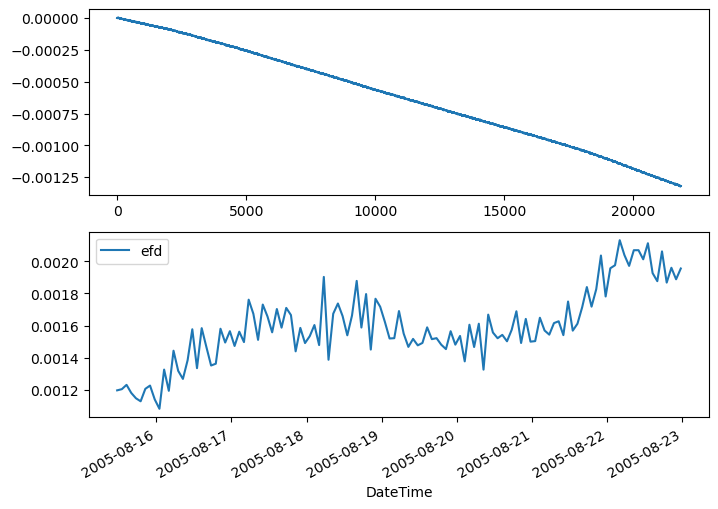

In [33]:
fig, axis = plt.subplots(2,1, figsize=(8,6))

axis[0].plot(edr_con['CHAMP'])
efd_con['CHAMP'].plot(x='DateTime',y='efd',ax=axis[1])

